# 01 - Exploratory Data Analysis

**Project**: Flu Shot Learning: Predict H1N1 and Seasonal Flu Vaccines

**Author**: Jarret Angbazo

**Date**: May 10, 2026

---

## Objective
Explore our dataset to understand:
- Data structure and quality
- Distribution of our target variables (h1n1_vaccine/seasonal_vaccine)
- Relationship between features and targets
- Differences between the target variables

## 1. Setup and Imports

In [682]:
# Standard libraries
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load Data

In [683]:
# Define paths
DATA_PATH = Path('../data/raw')

# Load training features and labels
flu_features_train = pd.read_csv(DATA_PATH / 'training_set_features.csv')
flu_labels_train = pd.read_csv(DATA_PATH / 'training_set_labels.csv')

# Load test features
flu_features_test = pd.read_csv(DATA_PATH / 'test_set_features.csv')

In [684]:
# Inspect flu train features dataframe
print(flu_features_train.shape)         # Check the shape of the training features dataframe
flu_features_train.head()


(26707, 36)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb


In [685]:
print(flu_features_train['respondent_id'].duplicated().sum())     # Check for duplicate respondent_id
print(flu_features_train['respondent_id'].isnull().sum())         # Check for missing respondent_id

# If duplicate respondent_id exists, list them to investigate further
if flu_features_train['respondent_id'].duplicated().any():
    print('Duplicated respondent_id:')
    print(flu_features_train[flu_features_train['respondent_id'].duplicated(keep=False)]['respondent_id'])
else:
    print('No duplicated respondent_id found.')

# If missing respondent_id exists, list them to investigate further
if flu_features_train['respondent_id'].isnull().any():
    print('Missing respondent_id:')
    print(flu_features_train[flu_features_train['respondent_id'].isnull()])
else:
    print('No missing respondent_id found.')

0
0
No duplicated respondent_id found.
No missing respondent_id found.


In [686]:
# Inspect flu train labels dataframe
print(flu_labels_train.shape)           # Check the shape of the training labels dataframe
flu_labels_train.head()

(26707, 3)


,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0


In [687]:
print(flu_labels_train['respondent_id'].duplicated().sum())     # Check for duplicate respondent_id
print(flu_labels_train['respondent_id'].isnull().sum())         # Check for missing respondent_id

# Check distribution of target variables
print(flu_labels_train['h1n1_vaccine'].value_counts())          # h1n1_vaccine distribution
print(flu_labels_train['seasonal_vaccine'].value_counts())      # seasonal_vaccine distribution

0
0
h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64
seasonal_vaccine
0    14272
1    12435
Name: count, dtype: int64


In [688]:
# Inspect flu test features dataframe
print(flu_features_test.shape)        # Check the shape of the test features dataframe
flu_features_test.head()

(26708, 36)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,26707,2.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,1.0,1.0,5.0,1.0,1.0,35 - 44 Years,College Graduate,Hispanic,Female,"> $75,000",Not Married,Rent,Employed,mlyzmhmf,"MSA, Not Principle City",1.0,0.0,atmlpfrs,hfxkjkmi
1,26708,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,1.0,4.0,1.0,1.0,18 - 34 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,Non-MSA,3.0,0.0,atmlpfrs,xqwwgdyp
2,26709,2.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,5.0,4.0,2.0,5.0,4.0,4.0,55 - 64 Years,College Graduate,White,Male,"> $75,000",Married,Own,Employed,lrircsnp,Non-MSA,1.0,0.0,nduyfdeo,pvmttkik
3,26710,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,4.0,2.0,2.0,4.0,4.0,2.0,65+ Years,12 Years,White,Female,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,lrircsnp,"MSA, Not Principle City",1.0,0.0,NaN,NaN
4,26711,3.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,2.0,4.0,4.0,4.0,2.0,35 - 44 Years,12 Years,Black,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,lzgpxyit,Non-MSA,0.0,1.0,fcxhlnwr,mxkfnird


In [689]:
print(flu_features_test['respondent_id'].duplicated().sum())     # Check for duplicate respondent_id
print(flu_features_test['respondent_id'].isnull().sum())         # Check for missing respondent_id

# If duplicate respondent_id exists, list them to investigate further
if flu_features_test['respondent_id'].duplicated().any():
    print('Duplicated respondent_id:')
    print(flu_features_test[flu_features_test['respondent_id'].duplicated(keep=False)]['respondent_id'])
else:
    print('No duplicated respondent_id found.')

# If missing respondent_id exists, list them to investigate further
if flu_features_test['respondent_id'].isnull().any():
    print('Missing respondent_id:')
    print(flu_features_test[flu_features_test['respondent_id'].isnull()])
else:
    print('No missing respondent_id found.')

0
0
No duplicated respondent_id found.
No missing respondent_id found.


In [690]:
# Merge training features and labels dataframes
flu_train_merged = flu_features_train.merge(flu_labels_train, on='respondent_id')
flu_train_merged.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


## 3. Initial Data Inspection

In [691]:
# Display basic information
# TODO: Show shape, dtypes, first few rows

print(flu_train_merged.shape)  # Shape of the merged training dataframe

print(flu_train_merged.dtypes) # dtypes of each column

# First few rows of merged training dataframe
flu_train_merged.head()

(26707, 38)
respondent_id                    int64
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
doctor_recc_seasonal           float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
opinion_seas_sick_from_vacc    float64
age_group                       object
education                       object
race                            object
sex          

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


### Check for Missing Values

In [1102]:
TARGET_COLS = ['h1n1_vaccine', 'seasonal_vaccine']
ID_COL = 'respondent_id'

# Columns with at least one missing value
cols_with_missing = [
    c for c in flu_train_merged.columns if flu_train_merged[c].isnull().any() and c not in TARGET_COLS + [ID_COL]
]

numeric_missing = [c for c in cols_with_missing if flu_train_merged[c].dtype in ['int64', 'float64']]
categorical_missing = [c for c in cols_with_missing if flu_train_merged[c].dtype == 'object']

print("=" * 50)
print("Missingness Summary")
print("=" * 50)
print(f"Number of columns with missing values: {len(cols_with_missing)}")
print(f"    Numeric:                           {len(numeric_missing)}")
print(f"    Categorical:                       {len(categorical_missing)}")

Missingness Summary
Number of columns with missing values: 30
    Numeric:                           23
    Categorical:                       7


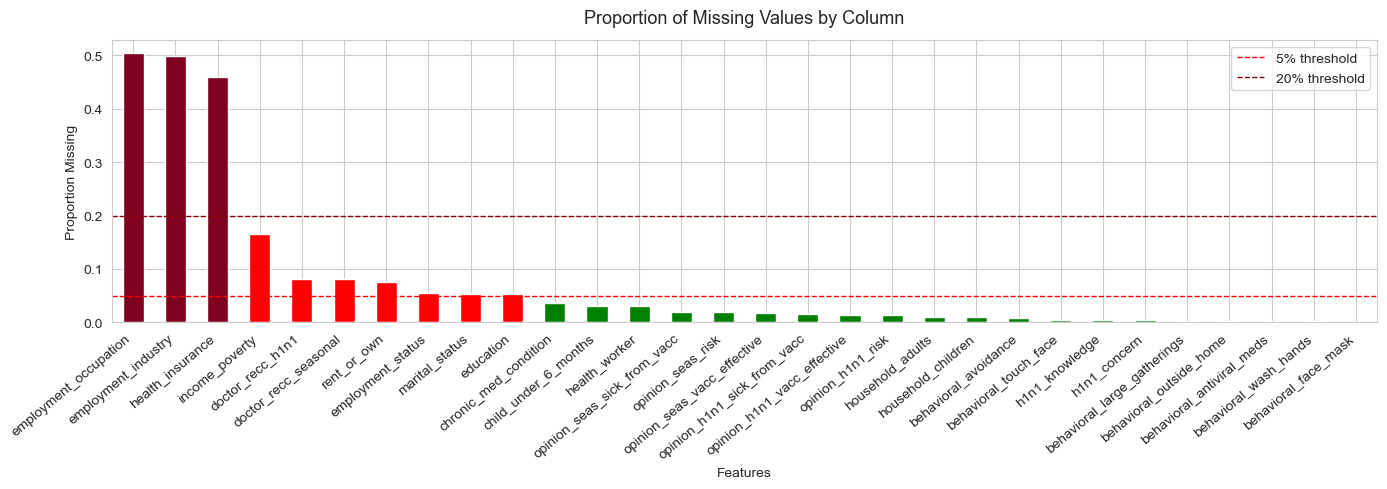

Columns with >20% missing values:
employment_occupation    0.504
employment_industry      0.499
health_insurance         0.460
dtype: float64


In [1241]:
# Missing Value Bar Chart
# Shows the proportion of missing values per column
fig, ax = plt.subplots(figsize=(14, 5))

missing_pct = (flu_train_merged[cols_with_missing].isnull().mean().sort_values(ascending=False))

colors = ['#800020' if v > 0.20 else '#FF0000' if v > 0.05 else '#008000' for v in missing_pct]
missing_pct.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
#plt.figure(figsize=(14, 5))
#missing_pct = (flu_train_merged.isnull().sum() / len(flu_train_merged)).sort_values(ascending=False)
#missing_pct = missing_pct[missing_pct > 0]          # Filter to show only columns with missing values

#missing_pct.plot(kind = 'bar', color = '#ED7D31', edgecolor = 'white')
ax.axhline(0.05, color='red', linestyle='--', linewidth=1, label='5% threshold')
ax.axhline(0.20, color='darkred', linestyle='--', linewidth=1, label='20% threshold')
ax.set_title('Proportion of Missing Values by Column', fontsize=13, pad=12)
ax.set_ylabel('Proportion Missing')
ax.set_xlabel('Features')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/missing_01_missing_value_bar_chart.png', dpi=150)
plt.show()

print("Columns with >20% missing values:")
print(missing_pct[missing_pct > 0.20].round(3))

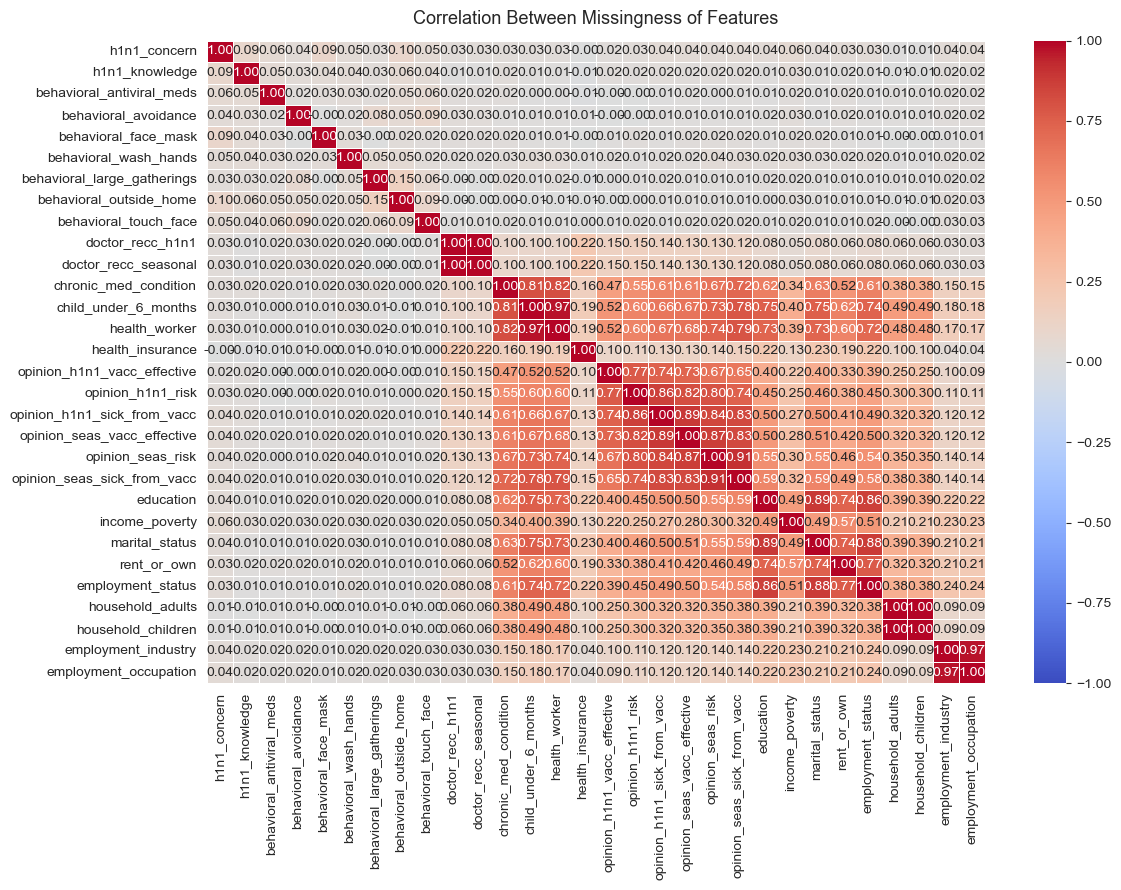

Strongest co-missingness correlations:
household_adults             household_children             1.000
doctor_recc_h1n1             doctor_recc_seasonal           1.000
employment_industry          employment_occupation          0.973
child_under_6_months         health_worker                  0.970
opinion_seas_risk            opinion_seas_sick_from_vacc    0.912
education                    marital_status                 0.888
opinion_h1n1_sick_from_vacc  opinion_seas_vacc_effective    0.885
marital_status               employment_status              0.876
opinion_seas_vacc_effective  opinion_seas_risk              0.868
education                    employment_status              0.864
dtype: float64


In [1242]:
# Missingness correlation heatmap
# Shows whether features tend to be missing together, which can indicate underlying patterns

missing_indicators = flu_train_merged[cols_with_missing].isnull().astype(int) # Create a binary indicator matrix (1 = missing, 0 = not missing)
corr_matrix = missing_indicators.corr() # Compute correlation matrix of missing indicators

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1,
            vmax=1,
            linewidth=0.5,
            ax=ax)
ax.set_title('Correlation Between Missingness of Features', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../reports/figures/missing_02_missingness_correlation_matrix.png', dpi=150)
plt.show()

# Print the strongest co-missingness pairs for reference
pairs = (corr_matrix
         .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
         .stack()
         .sort_values(ascending=False))

print("=" * 50)
print("Strongest co-missingness correlations:")
print("=" * 50)
print(pairs.head(10).round(3))


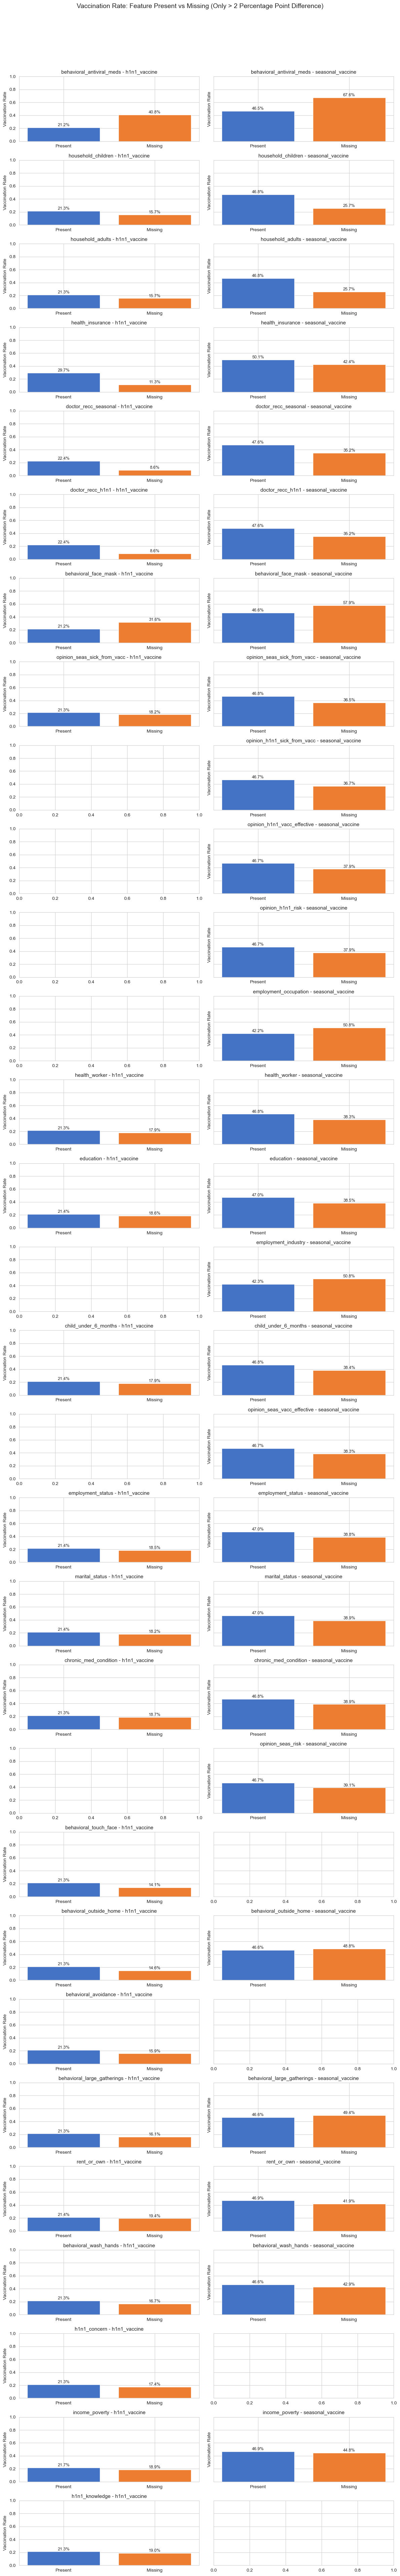

In [1243]:
# Target Rate by Missingness
# If vaccination rates differ between rows where a feature is present or missing, the missingness is related to the outcome (MNAR)

records = []
for col in cols_with_missing:
    mask = flu_train_merged[col].isnull()
    for target in TARGET_COLS:
        rate_present = flu_train_merged.loc[~mask, target].mean()       # Vaccination rate where feature is present
        rate_missing = flu_train_merged.loc[mask, target].mean()        # Vaccination rate where feature is missing
        records.append({
            'feature': col,
            'target': target,
            'rate_present': rate_present,
            'rate_missing': rate_missing,
            'difference': abs(rate_present - rate_missing)
        })

rate_df = pd.DataFrame(records)

# Bar chart comparing vaccination rates for present vs missing (only plot features with > 2 percentage point difference)
plot_df = rate_df[rate_df['difference'] > 0.02].sort_values('difference', ascending=False)

if len(plot_df) == 0:
    print("No features with > 2 percentage point difference in vaccination rates between present and missing. Weak MNAR signal.")
else:
    n_features = plot_df['feature'].nunique()
    fig, axes = plt.subplots(
        n_features, 2,
        figsize=(12, n_features * 2.5),
        sharey=True
    )
    # Handle single-row case
    if n_features == 1:
        axes = np.array([axes]) # Ensure axes is always 2D for consistent indexing

    for i, feature in enumerate(plot_df['feature'].unique()):
        subset = plot_df[plot_df['feature'] == feature]
        for j, target in enumerate(TARGET_COLS):
            ax = axes[i, j]
            row = subset[subset['target'] == target]
            if len(row) == 0:
                continue
            bars = ax.bar(
                ['Present', 'Missing'],
                [row['rate_present'].values[0],
                 row['rate_missing'].values[0]],
                 color=['#4472C4', '#ED7D31'],
                 edgecolor='white'
            )
            ax.set_title(f'{feature} - {target}', fontsize=11)
            ax.set_ylim(0, 1)
            ax.set_ylabel('Vaccination Rate')
            for bar in bars:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.02,
                    f'{bar.get_height():.1%}',
                    ha='center', fontsize=9
                )

plt.suptitle(
    'Vaccination Rate: Feature Present vs Missing (Only > 2 Percentage Point Difference)', fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig('../reports/figures/missing_03_vaccination_rate_by_missingness.png', dpi=150, bbox_inches='tight')
plt.show()

In [1244]:
# Little's MCAR Test
# Statistical test to determine if data is Missing Completely At Random (MCAR). The only formal test specifically for MCAR. A non-significant p-value (p > 0.05) suggests that the data is consistent with MCAR, while a significant p-value (p < 0.05) indicates that the data is not MCAR (could be MAR or MNAR).
from pyampute.exploration.mcar_statistical_tests import MCARTest

if len(numeric_missing) == 0:
    print("No numeric columns with missing values found. Little's MCAR Test cannot be performed.")
    p_little = None
else:
    mcar_test = MCARTest(method = 'little')
    p_little = mcar_test.little_mcar_test(flu_train_merged[numeric_missing])
    print("=" * 50)
    print("Little's MCAR Test Results")
    print("=" * 50)
    print(f"p-value: {p_little:.4f}")
    if p_little < 0.05:
        print("Reject null hypothesis. Missingness in numeric features not at random (could be MAR or MNAR)")
    else:
        print("Do not reject null hypothesis. Missingness in numeric features maybe at random (MCAR)")
        print()

Little's MCAR Test Results
p-value: 0.0000
Reject null hypothesis. Missingness in numeric features not at random (could be MAR or MNAR)


In [1245]:
# Chi-Squared Test for Categorical Missingness
# Chi-square tests whether the distribution of each categorical feature differs between rows where another feature is present vs missing. A significant result (p < 0.05) suggests that the missingness of one feature is related to the distribution of another, indicating that the data is not MCAR.
from scipy.stats import chi2_contingency

chi2_results = []

for col_missing in categorical_missing:
    mask = flu_train_merged[col_missing].isnull()

    # Test against all categorical features
    for col_cat in categorical_missing:
        if col_cat == col_missing:
            continue

        contingency = pd.crosstab(
            flu_train_merged[col_cat].fillna('__missing__'),
            mask
        )
        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            continue  # Skip if not enough data for chi-squared test

        chi2, p_val, dof, _ = chi2_contingency(contingency)
        chi2_results.append({
            'missing_feature': col_missing,
            'predictor_feature': col_cat,
            'chi2': round(chi2, 3),
            'p_value': round(p_val, 4),
            'significant_mar': p_val < 0.05
        })

chi2_df = pd.DataFrame(chi2_results)

# Summarize how many significant relationships per missing column
chi2_summary = (chi2_df.groupby('missing_feature')['significant_mar']
                .sum()
                .reset_index()
                .rename(columns={'significant_mar': 'n_significant_relationships'})
                .sort_values('n_significant_relationships', ascending=False))

print("=" * 50)
print("Chi-Squared Test for MAR Summary")
print("=" * 50)
print("Number of significant categorical predictors of missingness:")
print(chi2_summary.to_string(index=False))
print("\nInterpretation: higher count = stronger MAR signal for that column (missingness related to other observed features)")

Chi-Squared Test for MAR Summary
Number of significant categorical predictors of missingness:
      missing_feature  n_significant_relationships
            education                            6
  employment_industry                            6
employment_occupation                            6
    employment_status                            6
       income_poverty                            6
       marital_status                            6
          rent_or_own                            6

Interpretation: higher count = stronger MAR signal for that column (missingness related to other observed features)


In [1246]:
# Logistic Regression AUC on Missingness Indicator
# If we can predict missingness of a feature with high accuracy using other features, it suggests that the data is not MCAR (could be MAR or MNAR). AUC > 0.7 is often considered a strong signal that missingness is related to other observed data.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

logreg_results = []

# Use all non-target, non-ID numeric features as predictors
predictor_cols = [
    c for c in flu_train_merged.select_dtypes(include='number').columns
    if c not in TARGET_COLS + [ID_COL]
]

X_base = flu_train_merged[predictor_cols].fillna(
    flu_train_merged[predictor_cols].median()
)
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_base)

for col_missing in categorical_missing:
    y_missing = flu_train_merged[col_missing].isnull().astype(int)

    # Need at least some missing values to fit a model
    if y_missing.sum() < 20:
        continue

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_scaled, y_missing)
    auc = roc_auc_score(y_missing, model.predict_proba(X_scaled)[:, 1])

    if auc > 0.65:
        interpretation = 'Strong MAR signal'
    elif auc > 0.55:
        interpretation = 'Moderate MAR signal'
    else:
        interpretation = 'Consistent with MCAR'

    logreg_results.append({
        'feature':         col_missing,
        'missingness_auc': round(auc, 4),
        'interpretation':  interpretation
    })

logreg_df = (pd.DataFrame(logreg_results)
             .sort_values('missingness_auc', ascending=False))

print("=" * 50)
print("Logistic Regression — Missingness Predictability")
print("=" * 50)
print(logreg_df.to_string(index=False))
print("\nAUC > 0.65: Strong MAR | 0.55–0.65: Moderate MAR | < 0.55: MCAR consistent")

Logistic Regression — Missingness Predictability
              feature  missingness_auc      interpretation
            education           0.7427   Strong MAR signal
       marital_status           0.7330   Strong MAR signal
    employment_status           0.7328   Strong MAR signal
  employment_industry           0.7051   Strong MAR signal
employment_occupation           0.7017   Strong MAR signal
          rent_or_own           0.6773   Strong MAR signal
       income_poverty           0.6332 Moderate MAR signal

AUC > 0.65: Strong MAR | 0.55–0.65: Moderate MAR | < 0.55: MCAR consistent


In [1247]:
# Final Summary Table
summary_records = []

for col in cols_with_missing:
    missing_pct_val = flu_train_merged[col].isnull().mean()

    # Max target rate difference across both labels
    col_rates = rate_df[rate_df['feature'] == col]['difference']
    max_target_diff = col_rates.max() if len(col_rates) > 0 else 0

    # Logistic AUC
    auc_row = logreg_df[logreg_df['feature'] == col]
    auc_val = auc_row['missingness_auc'].values[0] if len(auc_row) > 0 else None

    # Chi-square significant relationships
    chi2_row = chi2_summary[chi2_summary['missing_feature'] == col]
    n_chi2   = chi2_row['n_significant_relationships'].values[0] \
               if len(chi2_row) > 0 else 0

    # Determine likely mechanism
    if max_target_diff > 0.05:
        mechanism = 'MNAR (likely)'
    elif (auc_val and auc_val > 0.65) or n_chi2 >= 2:
        mechanism = 'MAR (likely)'
    elif p_little and p_little < 0.05:
        mechanism = 'MAR or MNAR'
    else:
        mechanism = 'MCAR (possible)'

    # Recommended action
    if mechanism == 'MNAR (likely)':
        action = 'Add missingness indicator column + impute'
    elif 'MAR' in mechanism:
        action = 'Impute using other features (median/mode safe)'
    else:
        action = 'Simple median/mode imputation is valid'

    summary_records.append({
        'feature':           col,
        'pct_missing':       f"{missing_pct_val:.1%}",
        'target_rate_diff':  f"{max_target_diff:.3f}",
        'missingness_auc':   f"{auc_val:.3f}" if auc_val else 'N/A',
        'chi2_sig_rels':     n_chi2,
        'likely_mechanism':  mechanism,
        'recommended_action': action
    })

summary_df = pd.DataFrame(summary_records).sort_values('pct_missing', ascending=False)

print("=" * 70)
print("MISSINGNESS ANALYSIS SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))

MISSINGNESS ANALYSIS SUMMARY
                    feature pct_missing target_rate_diff missingness_auc  chi2_sig_rels likely_mechanism                             recommended_action
           doctor_recc_h1n1        8.1%            0.138             N/A              0    MNAR (likely)      Add missingness indicator column + impute
       doctor_recc_seasonal        8.1%            0.138             N/A              0    MNAR (likely)      Add missingness indicator column + impute
                rent_or_own        7.6%            0.050           0.677              6    MNAR (likely)      Add missingness indicator column + impute
      employment_occupation       50.4%            0.086           0.702              6    MNAR (likely)      Add missingness indicator column + impute
          employment_status        5.5%            0.083           0.733              6    MNAR (likely)      Add missingness indicator column + impute
             marital_status        5.3%            0.081   

**Interpretation**
Most opinion columns are likely **MNAR**. People who skip questions about vaccine risk perception and effectiveness are systematically more hesitant, which means the missingness itself carries predictive signal. Adding a `missing_feature_count` column to our feature engineering may be worth doing.

In [1248]:
# Summary statistics
# TODO: Display descriptive statistics

## 4. Target Variable Analysis

In [1249]:
# Distribution of total_cases
# TODO: Create histogram/distribution plot

In [1250]:
# Total cases by city
# TODO: Compare distributions between San Juan and Iquitos

In [1251]:
# Statistical summary of target by city
# TODO: Calculate mean, median, std, min, max for each city

## 5. Temporal Analysis

In [1252]:
# Time series plot of cases
# TODO: Plot total_cases over time for each city

In [1253]:
# Seasonality analysis
# TODO: Analyze cases by month, quarter, or week of year

In [1254]:
# Year-over-year trends
# TODO: Compare patterns across years

## 6. Feature Analysis

In [1255]:
# Correlation analysis
# TODO: Create correlation heatmap of all features

In [1256]:
# Feature correlation with target
# TODO: Identify features most correlated with total_cases

In [1257]:
# Temperature features analysis
# TODO: Explore temperature variables (avg, min, max)

In [1258]:
# Precipitation features analysis
# TODO: Explore precipitation variables

In [1259]:
# Vegetation index (NDVI) analysis
# TODO: Explore vegetation features

## 7. Bivariate Analysis

In [1260]:
# Scatter plots: features vs target
# TODO: Create scatter plots for key features

In [1261]:
# Feature interactions
# TODO: Explore temperature-humidity, precipitation-vegetation interactions

## 8. City Comparison

In [1262]:
# Compare climate patterns between cities
# TODO: Side-by-side comparison of San Juan vs Iquitos

In [1263]:
# Feature distributions by city
# TODO: Create distribution plots for each city

## 9. Key Findings & Insights

### Summary of Findings:
1. **Data Quality**: 
   - TODO: Document missing data patterns
   - TODO: Note any data quality issues

2. **Target Variable**:
   - TODO: Describe distribution characteristics
   - TODO: Note city differences

3. **Temporal Patterns**:
   - TODO: Describe seasonality
   - TODO: Note trends over time

4. **Feature Relationships**:
   - TODO: List most important features
   - TODO: Note interesting correlations

### Implications for Modeling:
- TODO: What preprocessing is needed?
- TODO: What features should be engineered?
- TODO: Should cities be modeled separately?
- TODO: What model types might work well?

## 10. Next Steps

Based on this EDA:
1. TODO: Data cleaning priorities
2. TODO: Feature engineering ideas
3. TODO: Modeling approach considerations